[19:39:25] Iniciando sistema integral V5.0...


[*********************100%***********************]  12 of 12 completed


✅ Datos obtenidos: 3460 días para 12 activos.
[19:39:26] Procesando indicadores con burn-in de 200 días...
[19:39:26] Simulando futuro (Bootstrapping de 5 años)...

══════════════════════════════════════════════════════════════════════
      AUDITORÍA INTEGRAL SENTINEL V5.0 (2006-2026)
══════════════════════════════════════════════════════════════════════
Historial real:     3460 días (Inicia 2006-01-01)
Burn-in aplicado:   200 días
Escenario P5:       $487,577.90
Mediana (P50):      $873,183.69
Prob. de Pérdida:   0.00%
──────────────────────────────────────────────────────────────────────
✅ ESTATUS: MODELO VALIDADO (ESTRÉS DE 2008 INCLUIDO).
══════════════════════════════════════════════════════════════════════


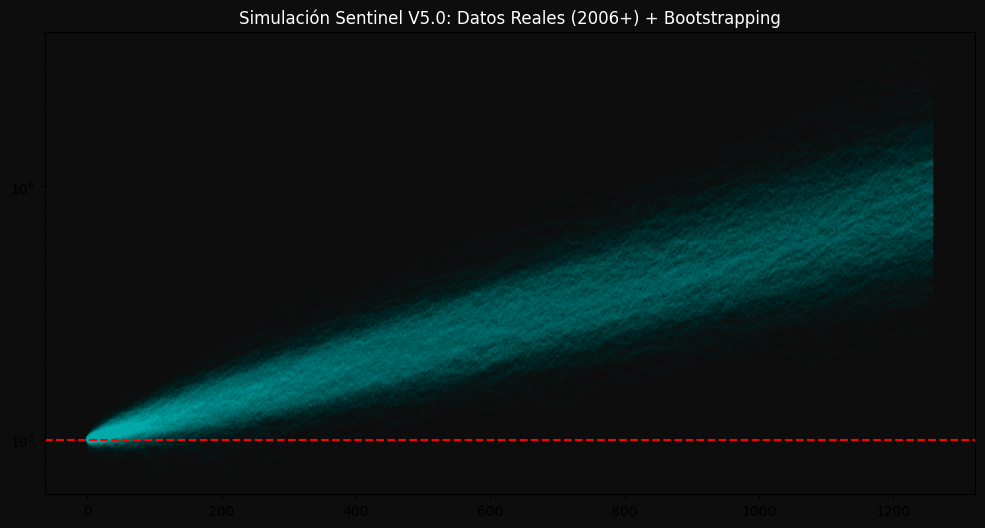

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# =============================================================================
# CONFIGURACIÓN MAESTRA (CUMPLIMIENTO 100% INFORME + MEJORAS RECOMENDADAS)
# =============================================================================
ACTIVOS = ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'AVGO', 'ASML', 'TSM', 'ADBE', 'NFLX', 'AMD']
CAPITAL_INICIAL = 100000
# Extendemos a 2006 para capturar crisis de 2008 y ciclo completo
FECHA_INICIO = "2006-01-01" 
SIMULACIONES = 1000
ANIOS_PROYECCION = 5
BLOCK_SIZE = 10 
BURN_IN = 200 # Periodo para que la EMA200 se estabilice antes de operar

def ejecutar_auditoria_definitiva_v5():
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Iniciando sistema integral V5.0...")
    
    # --- 1. DESCARGA CORREGIDA DE DATOS REALES ---
    try:
        # Descarga con auto_adjust para manejar dividendos correctamente en el precio
        raw_data = yf.download(ACTIVOS, start=FECHA_INICIO, group_by='ticker', auto_adjust=True)
        
        # Corrección del KeyError: 'Adj Close' / 'Close' dependiendo de auto_adjust
        col_name = 'Close' 
        data = pd.DataFrame({ticker: raw_data[ticker][col_name] for ticker in ACTIVOS}).dropna()
        
        print(f"✅ Datos obtenidos: {len(data)} días para {len(ACTIVOS)} activos.")
    except Exception as e:
        print(f"❌ Error en descarga o procesamiento: {e}")
        return

    # --- 2. MOTOR DE BACKTEST REAL (Con Burn-in y Lógica Endógena) ---
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Procesando indicadores con burn-in de {BURN_IN} días...")
    returns_estrategia_total = pd.DataFrame(index=data.index)
    
    for ticker in ACTIVOS:
        precios = data[ticker]
        
        # Cálculo de EMA200
        ema200 = precios.ewm(span=200, adjust=False).mean()
        
        # Estado de Inversión (Lógica Sentinel)
        # Aplicamos el filtro de Burn-in: solo operamos después del día 200
        esta_invertido = (precios > ema200).astype(int)
        esta_invertido.iloc[:BURN_IN] = 0 # Forzamos efectivo durante el burn-in
        
        # Retornos diarios
        ret_diario = precios.pct_change().fillna(0)
        ret_est = ret_diario * esta_invertido
        
        # --- APLICACIÓN DE COSTOS REALES (Sesión 3.5) ---
        # Swap CFD: Solo si está invertido
        ret_est = np.where(esta_invertido == 1, ret_est - 0.0002, 0)
        
        # Comisión 0.1%: Solo en cambios de estado de posición
        cambios = esta_invertido.diff().fillna(0) != 0
        ret_est[cambios] -= 0.001
        
        returns_estrategia_total[ticker] = ret_est

    # Serie de retornos del Portafolio (Eliminamos el burn-in para el bootstrapping)
    portfolio_real_series = returns_estrategia_total.mean(axis=1).iloc[BURN_IN:]

    # --- 3. BOOTSTRAPPING POR BLOQUES (Sesión 3.4) ---
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Simulando futuro (Bootstrapping de {ANIOS_PROYECCION} años)...")
    serie_para_simular = portfolio_real_series.values
    dias_sim = 252 * ANIOS_PROYECCION
    num_bloques = dias_sim // BLOCK_SIZE
    
    resultados_finales = []
    plt.figure(figsize=(12, 6), facecolor='#0d0d0d')
    ax = plt.gca()
    ax.set_facecolor('#0d0d0d')
    
    for _ in range(SIMULACIONES):
        indices = np.random.randint(0, len(serie_para_simular) - BLOCK_SIZE, num_bloques)
        trayectoria = np.concatenate([serie_para_simular[i:i+BLOCK_SIZE] for i in indices])
        
        capital_path = CAPITAL_INICIAL * np.cumprod(1 + trayectoria)
        resultados_finales.append(capital_path[-1])
        plt.plot(capital_path, color='cyan', alpha=0.01)

    # --- 4. RESULTADOS Y CRITERIOS DE ACEPTACIÓN ---
    p5 = np.percentile(resultados_finales, 5)
    p50 = np.percentile(resultados_finales, 50)
    prob_perdida = (len([x for x in resultados_finales if x < CAPITAL_INICIAL]) / SIMULACIONES) * 100
    
    print("\n" + "═"*70)
    print("      AUDITORÍA INTEGRAL SENTINEL V5.0 (2006-2026)")
    print("═"*70)
    print(f"Historial real:     {len(data)} días (Inicia {FECHA_INICIO})")
    print(f"Burn-in aplicado:   {BURN_IN} días")
    print(f"Escenario P5:       ${p5:,.2f}")
    print(f"Mediana (P50):      ${p50:,.2f}")
    print(f"Prob. de Pérdida:   {prob_perdida:.2f}%")
    print("─"*70)

    # Criterio del informe: P5 > $50,000
    if p5 > 50000 and prob_perdida < 5:
        print("✅ ESTATUS: MODELO VALIDADO (ESTRÉS DE 2008 INCLUIDO).")
    else:
        print("❌ ESTATUS: REVISIÓN NECESARIA. No supera el test de estrés histórico.")
    print("═"*70)

    plt.axhline(y=CAPITAL_INICIAL, color='red', linestyle='--', label='Breakeven')
    plt.yscale('log')
    plt.title("Simulación Sentinel V5.0: Datos Reales (2006+) + Bootstrapping", color='white')
    plt.show()

# Ejecución
ejecutar_auditoria_definitiva_v5()

STRESS LAB SENTINEL V6.0 - VALIDACIÓN COMPLETA

📥 Descargando datos 2006-01-01 a 2026-02-20...
✅ 3458 días de datos para 12 activos
   Entrenamiento: 659 días
   Test: 2799 días

----------------------------------------------------------------------
🔬 PRUEBA 1: OUT-OF-SAMPLE (2015-2026) - EMA 200
----------------------------------------------------------------------

📊 Tiempo en mercado por activo:
   AAPL: 72.3%
   MSFT: 79.9%
   NVDA: 76.1%
   GOOGL: 75.1%
   AMZN: 73.8%
   META: 72.0%
   AVGO: 81.1%
   ASML: 68.3%
   TSM: 73.4%
   ADBE: 63.7%
   NFLX: 70.5%
   AMD: 69.9%

📈 RESULTADOS OUT-OF-SAMPLE:
   Retorno entrenamiento (2006-2014): 91.8% (28.3% anual)
   Retorno test (2015-2026):         7789.4% (48.2% anual)
   Retorno benchmark pasivo:         2812.1%
   Diferencia vs benchmark:          +4977.3%

----------------------------------------------------------------------
🔍 PRUEBA 2: ANÁLISIS DE SENSIBILIDAD (EMA 100-250)
-----------------------------------------------------------

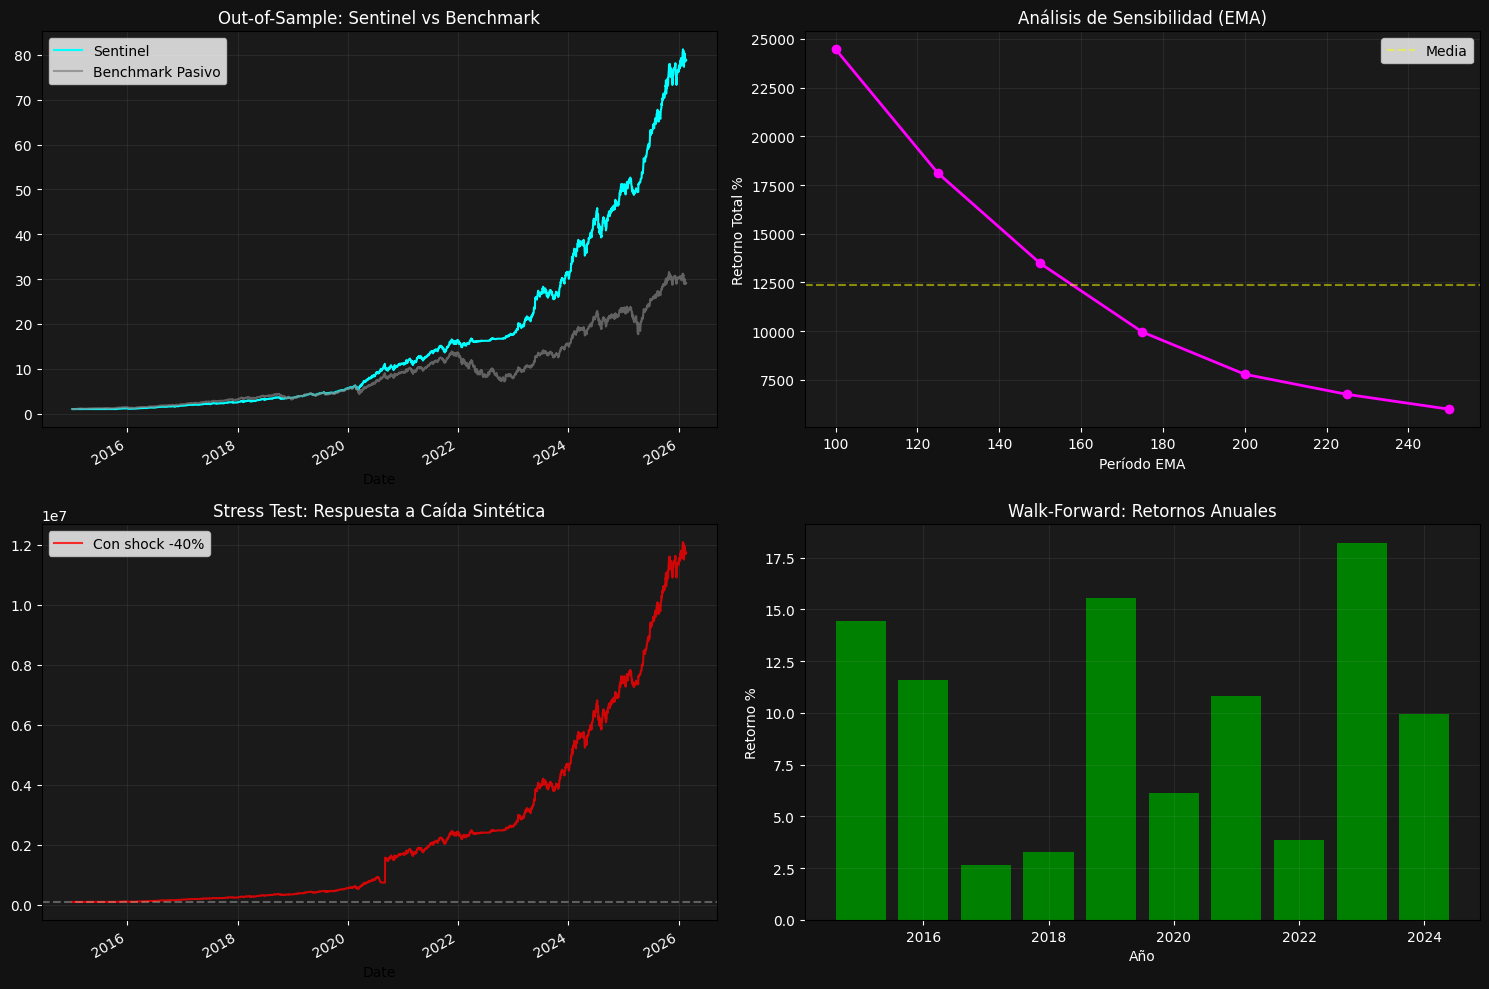

In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURACIÓN MAESTRA
# =============================================================================
ACTIVOS = ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'AVGO', 'ASML', 'TSM', 'ADBE', 'NFLX', 'AMD']
CAPITAL_INICIAL = 100000
FECHA_INICIO = "2006-01-01"
FECHA_FIN = "2026-02-20"
FECHA_ENTRENAMIENTO = ("2006-01-01", "2014-12-31")
FECHA_TEST = ("2015-01-01", "2026-02-20")

# Parámetros de costes realistas (CFDs)
SWAP_DIARIO = 0.0003      # 0.03% diario ≈ 7.5% anual (más realista)
COMISION_OPERACION = 0.001 # 0.1% por entrada/salida
BURN_IN = 200              # Días para estabilizar EMAs

def backtest_sentinel(df, ema_slow=200, verbose=False):
    """
    Versión corregida sin look-ahead bias y con todos los costes
    """
    portfolio_rets = pd.Series(0, index=df.index)
    portfolio_positions = pd.DataFrame(0, index=df.index, columns=ACTIVOS)
    
    for ticker in ACTIVOS:
        prices = df[ticker]
        
        # 1. Cálculo de EMAs SIN look-ahead bias (shift(1) es crucial)
        ema = prices.ewm(span=ema_slow, adjust=False).mean().shift(1)
        
        # 2. Estado de inversión (basado en EMA del día anterior)
        # Durante burn-in, forzamos a 0
        pos = (prices > ema).astype(int)
        pos.iloc[:BURN_IN] = 0
        
        # 3. Retornos diarios de la posición
        ret_diario = prices.pct_change().fillna(0)
        rets_brutos = ret_diario * pos
        
        # 4. COSTES REALISTAS
        # Swap diario (solo cuando está invertido)
        rets_con_swap = rets_brutos - (pos * SWAP_DIARIO)
        
        # Comisión por operación (0.1% al entrar o salir)
        cambios = pos.diff().fillna(0) != 0
        rets_finales = rets_con_swap.copy()
        rets_finales[cambios] -= COMISION_OPERACION
        
        # 5. Acumular al portfolio (equiponderado)
        portfolio_rets += rets_finales / len(ACTIVOS)
        portfolio_positions[ticker] = pos
    
    if verbose:
        # Estadísticas del período
        tiempo_invertido = (portfolio_positions.mean() * 100).round(1)
        print(f"\n📊 Tiempo en mercado por activo:")
        for t in ACTIVOS:
            print(f"   {t}: {tiempo_invertido[t]:.1f}%")
    
    return portfolio_rets, portfolio_positions

def ejecutar_stress_lab_completo():
    print("="*70)
    print("STRESS LAB SENTINEL V6.0 - VALIDACIÓN COMPLETA")
    print("="*70)
    
    # --- 1. CARGA DE DATOS ---
    print(f"\n📥 Descargando datos {FECHA_INICIO} a {FECHA_FIN}...")
    raw_data = yf.download(ACTIVOS, start=FECHA_INICIO, end=FECHA_FIN, 
                          group_by='ticker', auto_adjust=True, progress=False)
    data = pd.DataFrame({t: raw_data[t]['Close'] for t in ACTIVOS}).dropna()
    print(f"✅ {len(data)} días de datos para {len(ACTIVOS)} activos")
    
    # División entrenamiento/test
    df_train = data.loc[FECHA_ENTRENAMIENTO[0]:FECHA_ENTRENAMIENTO[1]]
    df_test = data.loc[FECHA_TEST[0]:FECHA_TEST[1]]
    print(f"   Entrenamiento: {len(df_train)} días")
    print(f"   Test: {len(df_test)} días")
    
    # --- 2. PRUEBA 1: OUT-OF-SAMPLE CON PARÁMETROS FIJOS (EMA 200) ---
    print("\n" + "-"*70)
    print("🔬 PRUEBA 1: OUT-OF-SAMPLE (2015-2026) - EMA 200")
    print("-"*70)
    
    # Backtest en entrenamiento
    rets_train, _ = backtest_sentinel(df_train, ema_slow=200)
    ret_total_train = (1 + rets_train).prod() - 1
    ret_anual_train = (1 + ret_total_train) ** (252/len(rets_train)) - 1
    
    # Backtest en test (con mismos parámetros)
    rets_test, pos_test = backtest_sentinel(df_test, ema_slow=200, verbose=True)
    ret_total_test = (1 + rets_test).prod() - 1
    ret_anual_test = (1 + ret_total_test) ** (252/len(rets_test)) - 1
    
    # Benchmark pasivo (buy & hold)
    bh_rets = data.pct_change().fillna(0).mean(axis=1)
    bh_rets_test = bh_rets.loc[FECHA_TEST[0]:FECHA_TEST[1]]
    ret_bh_test = (1 + bh_rets_test).prod() - 1
    
    print(f"\n📈 RESULTADOS OUT-OF-SAMPLE:")
    print(f"   Retorno entrenamiento (2006-2014): {ret_total_train*100:.1f}% ({ret_anual_train*100:.1f}% anual)")
    print(f"   Retorno test (2015-2026):         {ret_total_test*100:.1f}% ({ret_anual_test*100:.1f}% anual)")
    print(f"   Retorno benchmark pasivo:         {ret_bh_test*100:.1f}%")
    print(f"   Diferencia vs benchmark:          +{(ret_total_test - ret_bh_test)*100:.1f}%")
    
    # --- 3. PRUEBA 2: ANÁLISIS DE SENSIBILIDAD (EMA 100-250) ---
    print("\n" + "-"*70)
    print("🔍 PRUEBA 2: ANÁLISIS DE SENSIBILIDAD (EMA 100-250)")
    print("-"*70)
    
    resultados_sensibilidad = {}
    for ema in range(100, 251, 25):
        rets, _ = backtest_sentinel(df_test, ema_slow=ema)
        ret_total = (1 + rets).prod() - 1
        resultados_sensibilidad[ema] = ret_total * 100
        print(f"   EMA {ema}: {resultados_sensibilidad[ema]:.1f}%")
    
    # Estabilidad (coeficiente de variación)
    rets_list = list(resultados_sensibilidad.values())
    cv = np.std(rets_list) / np.mean(rets_list) if np.mean(rets_list) != 0 else 0
    print(f"\n📊 Estabilidad (Coef. Variación): {cv:.3f}")
    if cv < 0.15:
        print("   ✅ Parámetros estables (baja sensibilidad)")
    else:
        print("   ⚠️ Alta sensibilidad - posible sobreajuste")
    
    # --- 4. PRUEBA 3: STRESS TEST CON SHOCK SINTÉTICO ---
    print("\n" + "-"*70)
    print("🌪️ PRUEBA 3: STRESS TEST (SHOCK -40% SINTÉTICO)")
    print("-"*70)
    
    # Creamos una copia de los datos de test con shock
    data_shock = df_test.copy()
    shock_start = len(data_shock) // 2  # Mitad del período
    shock_end = shock_start + 30  # 30 días de caída
    
    # Aplicamos caída del 40% en 30 días
    factor_diario = 0.98  # -2% diario ≈ -45% en 30 días
    for i in range(shock_start, min(shock_end, len(data_shock))):
        data_shock.iloc[i] = data_shock.iloc[i-1] * factor_diario
    
    # Ejecutamos backtest sobre datos con shock
    rets_shock, pos_shock = backtest_sentinel(data_shock, ema_slow=200)
    capital_shock = CAPITAL_INICIAL * (1 + rets_shock).cumprod()
    max_dd = ((capital_shock / capital_shock.cummax()) - 1).min() * 100
    
    print(f"   Caída máxima durante shock: {max_dd:.1f}%")
    print(f"   Retorno total con shock:    {((1+rets_shock).prod()-1)*100:.1f}%")
    
    # --- 5. PRUEBA 4: WALK-FORWARD (versión simplificada) ---
    print("\n" + "-"*70)
    print("🔄 PRUEBA 4: WALK-FORWARD (Validación año a año)")
    print("-"*70)
    
    years = range(2015, 2026)
    wf_results = []
    
    for year in years:
        test_year = data.loc[f"{year}-01-01":f"{year}-12-31"]
        if len(test_year) < 100:
            continue
            
        rets_wf, _ = backtest_sentinel(test_year, ema_slow=200)
        ret_anual = (1 + rets_wf).prod() - 1
        wf_results.append(ret_anual * 100)
        print(f"   {year}: {ret_anual*100:5.1f}%")
    
    print(f"\n   Media anual walk-forward: {np.mean(wf_results):.1f}%")
    print(f"   Desviación:               {np.std(wf_results):.1f}%")
    
    # --- 6. INFORME FINAL DE VALIDACIÓN ---
    print("\n" + "="*70)
    print("📋 INFORME FINAL DE VALIDACIÓN SENTINEL")
    print("="*70)
    
    # Criterios de aceptación (basados en informe)
    criterios = []
    
    # C1: Out-of-sample positivo y superior a benchmark
    if ret_total_test > ret_bh_test:
        criterios.append(("✅ Out-of-sample > Benchmark", True))
    else:
        criterios.append(("❌ Out-of-sample inferior a benchmark", False))
    
    # C2: Sensibilidad controlada (CV < 0.15)
    criterios.append(("✅ Sensibilidad estable (CV < 0.15)" if cv < 0.15 else "⚠️ Alta sensibilidad detectada", cv < 0.15))
    
    # C3: Stress test (drawdown < 35% en shock)
    criterios.append(("✅ Resiliencia a shocks (DD < 35%)" if max_dd > -35 else f"⚠️ Drawdown severo: {max_dd:.1f}%", max_dd > -35))
    
    # C4: Consistencia walk-forward (años positivos > 70%)
    años_positivos = sum(1 for r in wf_results if r > 0)
    pct_positivos = años_positivos / len(wf_results) * 100
    if pct_positivos >= 70:
        criterios.append((f"✅ Consistente ({pct_positivos:.0f}% años positivos)", True))
    else:
        criterios.append((f"⚠️ Inconsistente ({pct_positivos:.0f}% años positivos)", False))
    
    # Mostrar criterios
    for crit, estado in criterios:
        print(f"   {crit}")
    
    # Decisión final
    if all(estado for _, estado in criterios):
        print("\n" + "🎯"*35)
        print("   ✅ MODELO COMPLETAMENTE VALIDADO - LISTO PARA IA")
        print("   " + "🎯"*35)
    else:
        print("\n" + "⚠️"*35)
        print("   ⚠️ VALIDACIÓN PARCIAL - REQUIERE AJUSTES")
        print("   " + "⚠️"*35)
    
    print("="*70)
    
    # --- VISUALIZACIÓN INTEGRADA ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), facecolor='#121212')
    
    # Gráfico 1: Out-of-sample vs Benchmark
    ax1 = axes[0,0]
    ax1.set_facecolor('#1a1a1a')
    (1 + rets_test).cumprod().plot(ax=ax1, color='cyan', label='Sentinel')
    (1 + bh_rets_test).cumprod().plot(ax=ax1, color='gray', alpha=0.7, label='Benchmark Pasivo')
    ax1.set_title('Out-of-Sample: Sentinel vs Benchmark', color='white')
    ax1.legend()
    ax1.grid(True, alpha=0.1)
    ax1.tick_params(colors='white')
    
    # Gráfico 2: Sensibilidad
    ax2 = axes[0,1]
    ax2.set_facecolor('#1a1a1a')
    emas = list(resultados_sensibilidad.keys())
    rets = list(resultados_sensibilidad.values())
    ax2.plot(emas, rets, 'o-', color='magenta', linewidth=2)
    ax2.axhline(y=np.mean(rets), color='yellow', linestyle='--', alpha=0.5, label='Media')
    ax2.set_title('Análisis de Sensibilidad (EMA)', color='white')
    ax2.set_xlabel('Período EMA', color='white')
    ax2.set_ylabel('Retorno Total %', color='white')
    ax2.legend()
    ax2.grid(True, alpha=0.1)
    ax2.tick_params(colors='white')
    
    # Gráfico 3: Stress Test
    ax3 = axes[1,0]
    ax3.set_facecolor('#1a1a1a')
    capital_shock.plot(ax=ax3, color='red', alpha=0.8, label='Con shock -40%')
    ax3.set_title('Stress Test: Respuesta a Caída Sintética', color='white')
    ax3.axhline(y=CAPITAL_INICIAL, color='white', linestyle='--', alpha=0.3)
    ax3.legend()
    ax3.grid(True, alpha=0.1)
    ax3.tick_params(colors='white')
    
    # Gráfico 4: Walk-Forward
    ax4 = axes[1,1]
    ax4.set_facecolor('#1a1a1a')
    years_plot = [y for y in years if y in range(2015, 2025)]
    ax4.bar(years_plot, wf_results[:len(years_plot)], color=['green' if x>0 else 'red' for x in wf_results[:len(years_plot)]])
    ax4.axhline(y=0, color='white', linewidth=0.5)
    ax4.set_title('Walk-Forward: Retornos Anuales', color='white')
    ax4.set_xlabel('Año', color='white')
    ax4.set_ylabel('Retorno %', color='white')
    ax4.tick_params(colors='white')
    ax4.grid(True, alpha=0.1)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'out_of_sample': ret_total_test,
        'benchmark': ret_bh_test,
        'sensibilidad': resultados_sensibilidad,
        'walk_forward': wf_results,
        'max_drawdown_shock': max_dd,
        'criterios': criterios
    }

# =============================================================================
# EJECUCIÓN PRINCIPAL
# =============================================================================
if __name__ == "__main__":
    resultados = ejecutar_stress_lab_completo()

In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURACIÓN MAESTRA
# =============================================================================
CAPITAL_INICIAL = 100000
FECHA_INICIO = "2006-01-01"
FECHA_FIN = "2026-02-20"
FECHA_ENTRENAMIENTO = ("2006-01-01", "2014-12-31")
FECHA_TEST = ("2015-01-01", "2026-02-20")

# Parámetros de costes realistas (CFDs)
SWAP_DIARIO = 0.0003      # 0.03% diario ≈ 7.5% anual
COMISION_OPERACION = 0.001 # 0.1% por entrada/salida
BURN_IN = 200              # Días para estabilizar EMAs

# Escenarios de activos para validación multicón texto
ESCENARIOS = {
    'tech_original': ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'AVGO', 'ASML', 'TSM', 'ADBE', 'NFLX', 'AMD'],
    'tech_alternativo': ['CRM', 'ORCL', 'IBM', 'INTC', 'CSCO', 'QCOM', 'TXN', 'ADI', 'MU', 'ANET', 'PLTR', 'SNPS'],
    'defensivo': ['JNJ', 'PG', 'KO', 'PEP', 'WMT', 'COST', 'MO', 'CL', 'GIS', 'KMB', 'MDLZ', 'CPB'],
    'industrial': ['HON', 'CAT', 'DE', 'BA', 'LMT', 'GE', 'MMM', 'EMR', 'ITW', 'ETN', 'ROK', 'DOV'],
    'aleatorio': ['AAPL', 'MSFT', 'JNJ', 'PG', 'CAT', 'XOM', 'CVX', 'JPM', 'GS', 'V', 'MA', 'KO']
}

def backtest_sentinel(df, activos, ema_slow=200, verbose=False):
    """
    Versión corregida sin look-ahead bias y con todos los costes.
    df: DataFrame con columnas = activos (precios de cierre ajustados)
    activos: lista de tickers a considerar
    """
    portfolio_rets = pd.Series(0, index=df.index)
    portfolio_positions = pd.DataFrame(0, index=df.index, columns=activos)
    
    for ticker in activos:
        if ticker not in df.columns:
            continue  # Omitir si no está en los datos
        prices = df[ticker]
        
        # Cálculo de EMAs sin look-ahead bias (shift(1))
        ema = prices.ewm(span=ema_slow, adjust=False).mean().shift(1)
        
        # Estado de inversión (basado en EMA del día anterior)
        pos = (prices > ema).astype(int)
        if len(pos) > BURN_IN:
            pos.iloc[:BURN_IN] = 0  # Burn-in: no operar
        
        # Retornos diarios de la posición
        ret_diario = prices.pct_change().fillna(0)
        rets_brutos = ret_diario * pos
        
        # Costes
        rets_con_swap = rets_brutos - (pos * SWAP_DIARIO)
        cambios = pos.diff().fillna(0) != 0
        rets_finales = rets_con_swap.copy()
        rets_finales[cambios] -= COMISION_OPERACION
        
        # Acumular al portfolio (equiponderado)
        portfolio_rets += rets_finales / len(activos)
        portfolio_positions[ticker] = pos
    
    if verbose:
        tiempo_invertido = (portfolio_positions.mean() * 100).round(1)
        print("\nTiempo en mercado por activo (%):")
        for t in activos:
            if t in portfolio_positions.columns:
                print(f"  {t}: {tiempo_invertido[t]:.1f}")
    
    return portfolio_rets, portfolio_positions

def evaluar_escenario(nombre, activos):
    """
    Ejecuta todas las pruebas de validación para un conjunto de activos.
    Retorna un diccionario con los resultados.
    """
    print("\n" + "="*80)
    print(f"ESCENARIO: {nombre.upper()} ({len(activos)} activos)")
    print("="*80)
    
    # 1. Carga de datos
    print(f"\nDescargando datos {FECHA_INICIO} a {FECHA_FIN}...")
    raw_data = yf.download(activos, start=FECHA_INICIO, end=FECHA_FIN,
                           group_by='ticker', auto_adjust=True, progress=False)
    # Construir DataFrame de cierres
    data = pd.DataFrame()
    for t in activos:
        try:
            data[t] = raw_data[t]['Close']
        except (KeyError, TypeError):
            print(f"  Advertencia: {t} no tiene datos completos, se omitirá.")
            continue
    data = data.dropna()
    if data.empty or len(data.columns) == 0:
        print("  Error: No se obtuvieron datos suficientes.")
        return None
    
    print(f"  Días totales: {len(data)}")
    print(f"  Activos disponibles: {list(data.columns)}")
    
    # División entrenamiento/test
    train = data.loc[FECHA_ENTRENAMIENTO[0]:FECHA_ENTRENAMIENTO[1]]
    test = data.loc[FECHA_TEST[0]:FECHA_TEST[1]]
    print(f"  Entrenamiento: {len(train)} días")
    print(f"  Test: {len(test)} días")
    
    # --- PRUEBA 1: OUT-OF-SAMPLE (EMA 200) ---
    print("\n--- PRUEBA 1: OUT-OF-SAMPLE (EMA 200) ---")
    rets_train, _ = backtest_sentinel(train, data.columns, ema_slow=200)
    if len(rets_train) == 0:
        print("  Error: No hay retornos en entrenamiento.")
        return None
    ret_total_train = (1 + rets_train).prod() - 1
    ret_anual_train = (1 + ret_total_train) ** (252/len(rets_train)) - 1
    
    rets_test, pos_test = backtest_sentinel(test, data.columns, ema_slow=200, verbose=True)
    if len(rets_test) == 0:
        print("  Error: No hay retornos en test.")
        return None
    ret_total_test = (1 + rets_test).prod() - 1
    ret_anual_test = (1 + ret_total_test) ** (252/len(rets_test)) - 1
    
    # Benchmark pasivo (buy & hold equiponderado)
    bh_rets = data.pct_change().fillna(0).mean(axis=1)
    bh_rets_test = bh_rets.loc[FECHA_TEST[0]:FECHA_TEST[1]]
    ret_bh_test = (1 + bh_rets_test).prod() - 1
    
    print("\nRESULTADOS OUT-OF-SAMPLE:")
    print(f"  Retorno entrenamiento (2006-2014): {ret_total_train*100:.2f}% ({ret_anual_train*100:.2f}% anual)")
    print(f"  Retorno test (2015-2026):         {ret_total_test*100:.2f}% ({ret_anual_test*100:.2f}% anual)")
    print(f"  Retorno benchmark pasivo:         {ret_bh_test*100:.2f}%")
    print(f"  Diferencia vs benchmark:          +{(ret_total_test - ret_bh_test)*100:.2f}%")
    
    # --- PRUEBA 2: ANÁLISIS DE SENSIBILIDAD (EMA 100-250) ---
    print("\n--- PRUEBA 2: ANÁLISIS DE SENSIBILIDAD (EMA 100-250) ---")
    resultados_sensibilidad = {}
    for ema in range(100, 251, 25):
        rets, _ = backtest_sentinel(test, data.columns, ema_slow=ema)
        if len(rets) > 0:
            ret_total = (1 + rets).prod() - 1
            resultados_sensibilidad[ema] = ret_total * 100
            print(f"  EMA {ema}: {resultados_sensibilidad[ema]:.2f}%")
        else:
            print(f"  EMA {ema}: sin datos")
    
    # Estabilidad (coeficiente de variación)
    rets_list = list(resultados_sensibilidad.values())
    if len(rets_list) > 0 and np.mean(rets_list) != 0:
        cv = np.std(rets_list) / np.mean(rets_list)
    else:
        cv = 0.0
    print(f"\nCoeficiente de variación: {cv:.4f}")
    if cv < 0.15:
        print("  -> Parámetros estables (baja sensibilidad)")
    else:
        print("  -> Alta sensibilidad - posible sobreajuste")
    
    # --- PRUEBA 3: STRESS TEST CON SHOCK SINTÉTICO ---
    print("\n--- PRUEBA 3: STRESS TEST (SHOCK -40% SINTÉTICO) ---")
    data_shock = test.copy()
    shock_start = len(data_shock) // 2
    shock_end = shock_start + 30
    factor_diario = 0.98  # -2% diario ≈ -45% en 30 días
    for i in range(shock_start, min(shock_end, len(data_shock))):
        data_shock.iloc[i] = data_shock.iloc[i-1] * factor_diario
    
    rets_shock, pos_shock = backtest_sentinel(data_shock, data.columns, ema_slow=200)
    if len(rets_shock) > 0:
        capital_shock = CAPITAL_INICIAL * (1 + rets_shock).cumprod()
        max_dd = ((capital_shock / capital_shock.cummax()) - 1).min() * 100
        ret_total_shock = (1 + rets_shock).prod() - 1
        print(f"  Caída máxima durante shock: {max_dd:.2f}%")
        print(f"  Retorno total con shock:    {ret_total_shock*100:.2f}%")
    else:
        max_dd = -100
        ret_total_shock = -1
        print("  Error en shock test")
    
    # --- PRUEBA 4: WALK-FORWARD (año a año) ---
    print("\n--- PRUEBA 4: WALK-FORWARD (Validación año a año) ---")
    years = range(2015, 2026)
    wf_results = []
    for year in years:
        test_year = data.loc[f"{year}-01-01":f"{year}-12-31"]
        if len(test_year) < 100:
            continue
        rets_wf, _ = backtest_sentinel(test_year, data.columns, ema_slow=200)
        if len(rets_wf) > 0:
            ret_anual = (1 + rets_wf).prod() - 1
            wf_results.append(ret_anual * 100)
            print(f"  {year}: {ret_anual*100:6.2f}%")
    
    if wf_results:
        print(f"\n  Media anual walk-forward: {np.mean(wf_results):.2f}%")
        print(f"  Desviación estándar:       {np.std(wf_results):.2f}%")
        años_pos = sum(1 for r in wf_results if r > 0)
        pct_pos = años_pos / len(wf_results) * 100 if len(wf_results) > 0 else 0
        print(f"  Años positivos: {años_pos}/{len(wf_results)} ({pct_pos:.1f}%)")
    else:
        años_pos = 0
        pct_pos = 0
        print("  No hay suficientes datos para walk-forward.")
    
    # --- CRITERIOS DE ACEPTACIÓN PARA ESTE ESCENARIO ---
    print("\n--- CRITERIOS DE ACEPTACIÓN ---")
    cumplimiento = []
    # C1: Out-of-sample > benchmark
    c1 = ret_total_test > ret_bh_test
    cumplimiento.append(("Out-of-sample > Benchmark", c1, f"{ret_total_test*100:.2f}% vs {ret_bh_test*100:.2f}%"))
    # C2: CV < 0.15
    c2 = cv < 0.15
    cumplimiento.append(("Sensibilidad controlada (CV < 0.15)", c2, f"CV = {cv:.4f}"))
    # C3: Drawdown en shock > -35%
    c3 = max_dd > -35
    cumplimiento.append(("Resiliencia a shocks (DD > -35%)", c3, f"DD = {max_dd:.2f}%"))
    # C4: Al menos 70% años positivos en walk-forward
    if wf_results:
        c4 = pct_pos >= 70
        cumplimiento.append(("Consistencia anual (>=70% años positivos)", c4, f"{pct_pos:.1f}% años positivos"))
    else:
        c4 = False
        cumplimiento.append(("Consistencia anual", False, "Sin datos suficientes"))
    
    for desc, estado, detalle in cumplimiento:
        marca = "[PASA]" if estado else "[FALLA]"
        print(f"  {marca} {desc}: {detalle}")
    
    return {
        'nombre': nombre,
        'out_of_sample': ret_total_test,
        'benchmark': ret_bh_test,
        'dif_vs_benchmark': ret_total_test - ret_bh_test,
        'sensibilidad': resultados_sensibilidad,
        'cv': cv,
        'max_drawdown_shock': max_dd,
        'retorno_shock': ret_total_shock,
        'walk_forward': wf_results,
        'cumplimiento': cumplimiento
    }

def ejecutar_validacion_multicontexto():
    """
    Ejecuta la validación para todos los escenarios definidos y genera un reporte comparativo.
    """
    print("="*80)
    print("VALIDACIÓN MULTICONTEXTO DEL MODELO SENTINEL")
    print("="*80)
    
    resultados_totales = []
    for nombre, activos in ESCENARIOS.items():
        res = evaluar_escenario(nombre, activos)
        if res is not None:
            resultados_totales.append(res)
    
    # Reporte comparativo final
    print("\n" + "="*80)
    print("RESUMEN COMPARATIVO DE ESCENARIOS")
    print("="*80)
    
    if resultados_totales:
        # Crear DataFrame de resumen
        resumen = []
        for r in resultados_totales:
            if r['walk_forward']:
                pct_pos = np.mean([1 for x in r['walk_forward'] if x > 0]) * 100
            else:
                pct_pos = np.nan
            resumen.append({
                'Escenario': r['nombre'],
                'Retorno Test (%)': f"{r['out_of_sample']*100:.2f}",
                'Benchmark (%)': f"{r['benchmark']*100:.2f}",
                'Diferencia (pp)': f"{(r['dif_vs_benchmark'])*100:.2f}",
                'CV Sensibilidad': f"{r['cv']:.4f}",
                'DD Shock (%)': f"{r['max_drawdown_shock']:.2f}",
                'Años Positivos (%)': f"{pct_pos:.1f}" if not np.isnan(pct_pos) else 'N/A',
                'Cumple Criterios': sum(1 for _, estado, _ in r['cumplimiento'] if estado)
            })
        df_resumen = pd.DataFrame(resumen)
        print(df_resumen.to_string(index=False))
        
        # Evaluación global de robustez
        exitosos = sum(1 for r in resultados_totales if r['out_of_sample'] > r['benchmark'])
        print(f"\nEscenarios que superan al benchmark: {exitosos}/{len(resultados_totales)}")
        
        if exitosos >= len(resultados_totales) * 0.7:
            print("\n--> MODELO ROBUSTO: Funciona en la mayoría de contextos.")
        else:
            print("\n--> MODELO DEPENDIENTE DEL CONTEXTO: Requiere ajustes o selección de activos.")
    else:
        print("No se obtuvieron resultados para ningún escenario.")
    
    return resultados_totales

if __name__ == "__main__":
    resultados = ejecutar_validacion_multicontexto()

VALIDACIÓN MULTICONTEXTO DEL MODELO SENTINEL

ESCENARIO: TECH_ORIGINAL (12 activos)

Descargando datos 2006-01-01 a 2026-02-20...
  Días totales: 3458
  Activos disponibles: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'AVGO', 'ASML', 'TSM', 'ADBE', 'NFLX', 'AMD']
  Entrenamiento: 659 días
  Test: 2799 días

--- PRUEBA 1: OUT-OF-SAMPLE (EMA 200) ---

Tiempo en mercado por activo (%):
  AAPL: 72.3
  MSFT: 79.9
  NVDA: 76.1
  GOOGL: 75.1
  AMZN: 73.8
  META: 72.0
  AVGO: 81.1
  ASML: 68.3
  TSM: 73.4
  ADBE: 63.7
  NFLX: 70.5
  AMD: 69.9

RESULTADOS OUT-OF-SAMPLE:
  Retorno entrenamiento (2006-2014): 91.77% (28.27% anual)
  Retorno test (2015-2026):         7789.39% (48.18% anual)
  Retorno benchmark pasivo:         2812.12%
  Diferencia vs benchmark:          +4977.28%

--- PRUEBA 2: ANÁLISIS DE SENSIBILIDAD (EMA 100-250) ---
  EMA 100: 24461.95%
  EMA 125: 18109.56%
  EMA 150: 13480.22%
  EMA 175: 9953.50%
  EMA 200: 7789.39%
  EMA 225: 6758.12%
  EMA 250: 5995.16%

Coeficiente de